# Matching coupling before computing SPIs

Can SPI–SPI distinguish dynamics beyond per-SPI means when a declared generator-level interaction strength is matched? This is a new seven-condition exploratory experiment using the existing VAR and quadratic-CML generator families. It does not normalize individual MPIs or select examples according to which representation wins.

The primary comparison is the **mean of each MPI** versus **SPI–SPI**. Distribution summaries and validity are secondary controls. Classifying seven variants is a test of representation utility; it does not establish unique identification of a physical mechanism.

In [1]:
from pathlib import Path
import sys,json
ROOT=Path.cwd().resolve()
while not (ROOT/'pyproject.toml').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display
from scripts.calibrate_native_coupling import DATA,OUT
from scripts import analyze_native_coupling as study
rows=pd.DataFrame(json.loads((DATA/'manifest.json').read_text())['rows'])


## What is held fixed?

We define total cross-channel coupling as the mean row sum of the absolute off-diagonal Jacobian of one native update:

$$G(X)=\left\langle\sum_{j\ne i}\left|\frac{\partial F_i(x_t)}{\partial x_j}\right|\right\rangle_{i,t}=0.20\pm0.002.$$

For VAR, $F_i(x)=\phi x_i+\frac g2(x_{i-1}+x_{i+1})$, hence $G=g$ exactly; we set g=.2 for both self-memory settings $\phi\in\{.2,.7\}$. For quadratic CML, $f_\alpha(x)=1-\alpha x^2$ and $F_i=(1-g)f_\alpha(x_i)+\frac g2[f_\alpha(x_{i-1})+f_\alpha(x_{i+1})]$, so $G=g\alpha\langle|x_{i-1}|+|x_{i+1}|\rangle_{i,t}$. We calibrate g separately for each CML recording, with $\alpha\in\{1.45,1.69,1.7522,1.895,2.0\}$.

This **per-step linear-response gain** is an explicit strength convention, not a universal dependence scalar. It is computed from the actual generator Jacobian before any SPI and remains sensitive to coupling when channels synchronize. An earlier discarded calibration used the realized update contribution, which can vanish under synchrony even for strong coupling; it is not the primary experiment reported here. CML retains the original 100-site ring and 16-site crop (both neighbours, including those outside the crop, enter the known derivative); VAR observes its full 16-site ring. Both use 2,000 burn-in updates and 1,000 recorded samples. VAR coefficients remain below the stability bound without rescaling. CML labels give actual alpha values: changing coupling does not justify retaining historical regime names.

All channels are centered, and one common scale per recording sets mean channel variance to one. An affine change with a common scalar leaves the Jacobian unchanged, so this removes arbitrary global amplitude while preserving G. No individual MPI is normalized. Native and transformed recordings are retained; every condition retains all 24 requested realizations.

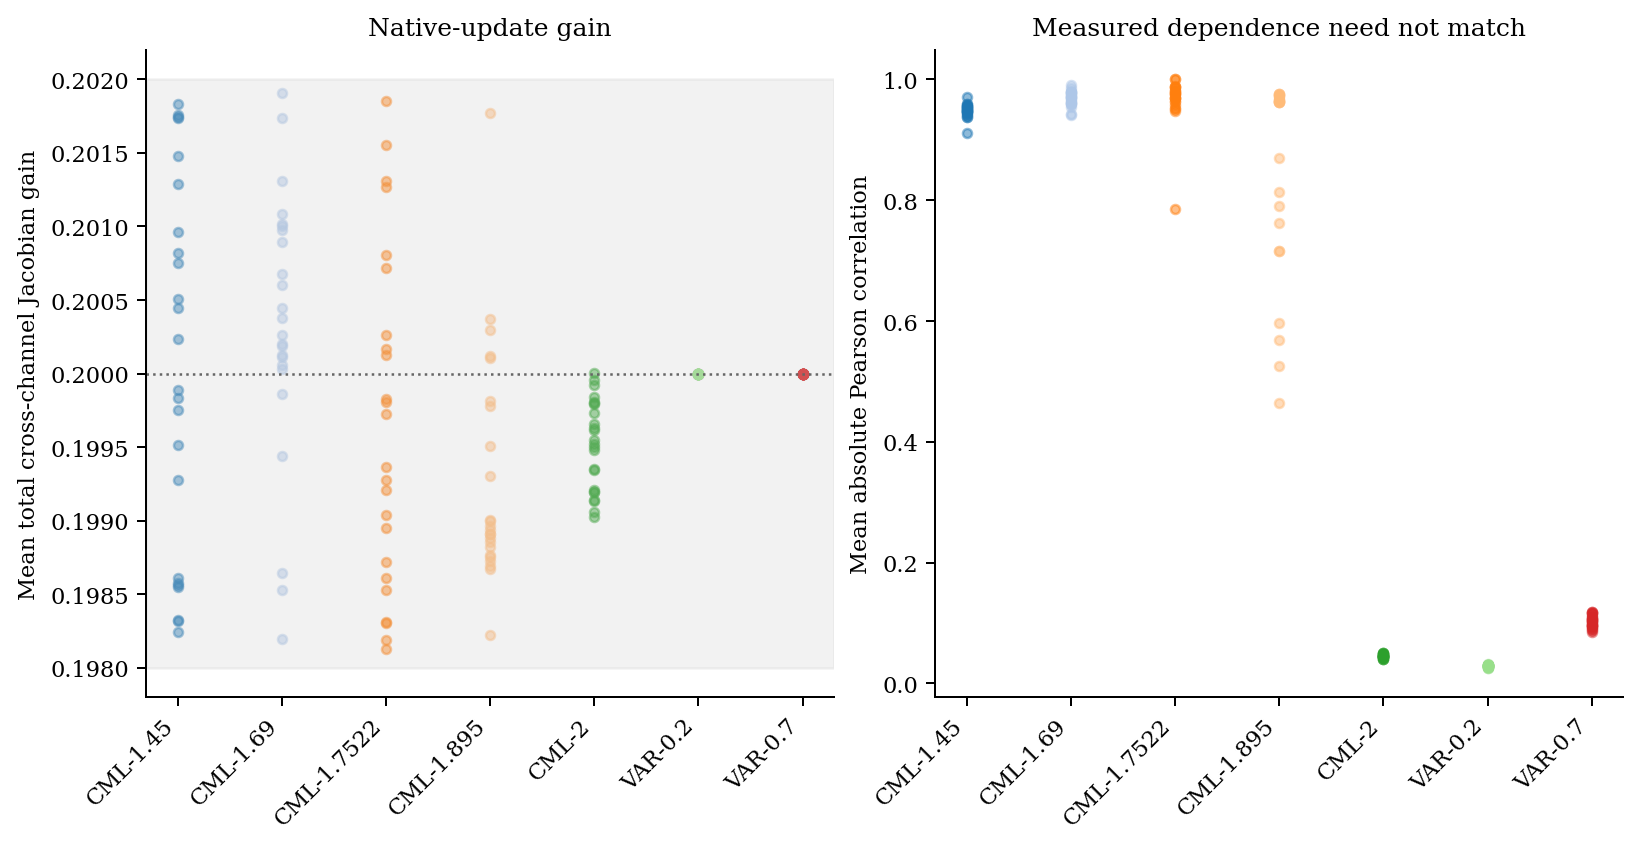

,n,strength_min,strength_max,native_g_min,native_g_max
label,,,,,
CML-1.45,24,0.1982,0.2018,0.1250,0.1344
CML-1.69,24,0.1982,0.2019,0.1172,0.1312
CML-1.7522,24,0.1981,0.2019,0.1156,0.1250
CML-1.895,24,0.1982,0.2018,0.1062,0.1094
CML-2,24,0.1990,0.2000,0.0938,0.0938
VAR-0.2,24,0.2000,0.2000,0.2000,0.2000
VAR-0.7,24,0.2000,0.2000,0.2000,0.2000


In [2]:
fig=study.plot_calibration()
plt.show()
display(rows.groupby('label').agg(n=('row_id','size'),strength_min=('strength','min'),strength_max=('strength','max'),native_g_min=('g','min'),native_g_max=('g','max')).round(4))

## Mean MPI versus SPI–SPI

Each condition has 24 paired seed groups: instances 0–11 supply development data; 12–23 supply evaluation data. All p90 MPIs use the same catalogue and serial estimator-seeding policy. We preserve ordered off-diagonal entries and keep undefined SPIs missing. Each representation uses development-only 95% feature validity, median imputation, SD scaling, clipping at ±5 SD, and up to 20 principal components. A fixed C=1 logistic classifier evaluates held realizations. The full-mean sensitivity omits PCA, retaining all selected mean features. It was specified before the SPI outcomes.

Both PCA and UMAP displays are fitted on development data and transform the evaluation recordings. UMAP uses 30 neighbours, min_dist=.1 and seed261003. Separate maps have arbitrary orientation and scale; visual gaps do not establish that information is absent. Classification is evaluated in the fitted representation, not in UMAP.

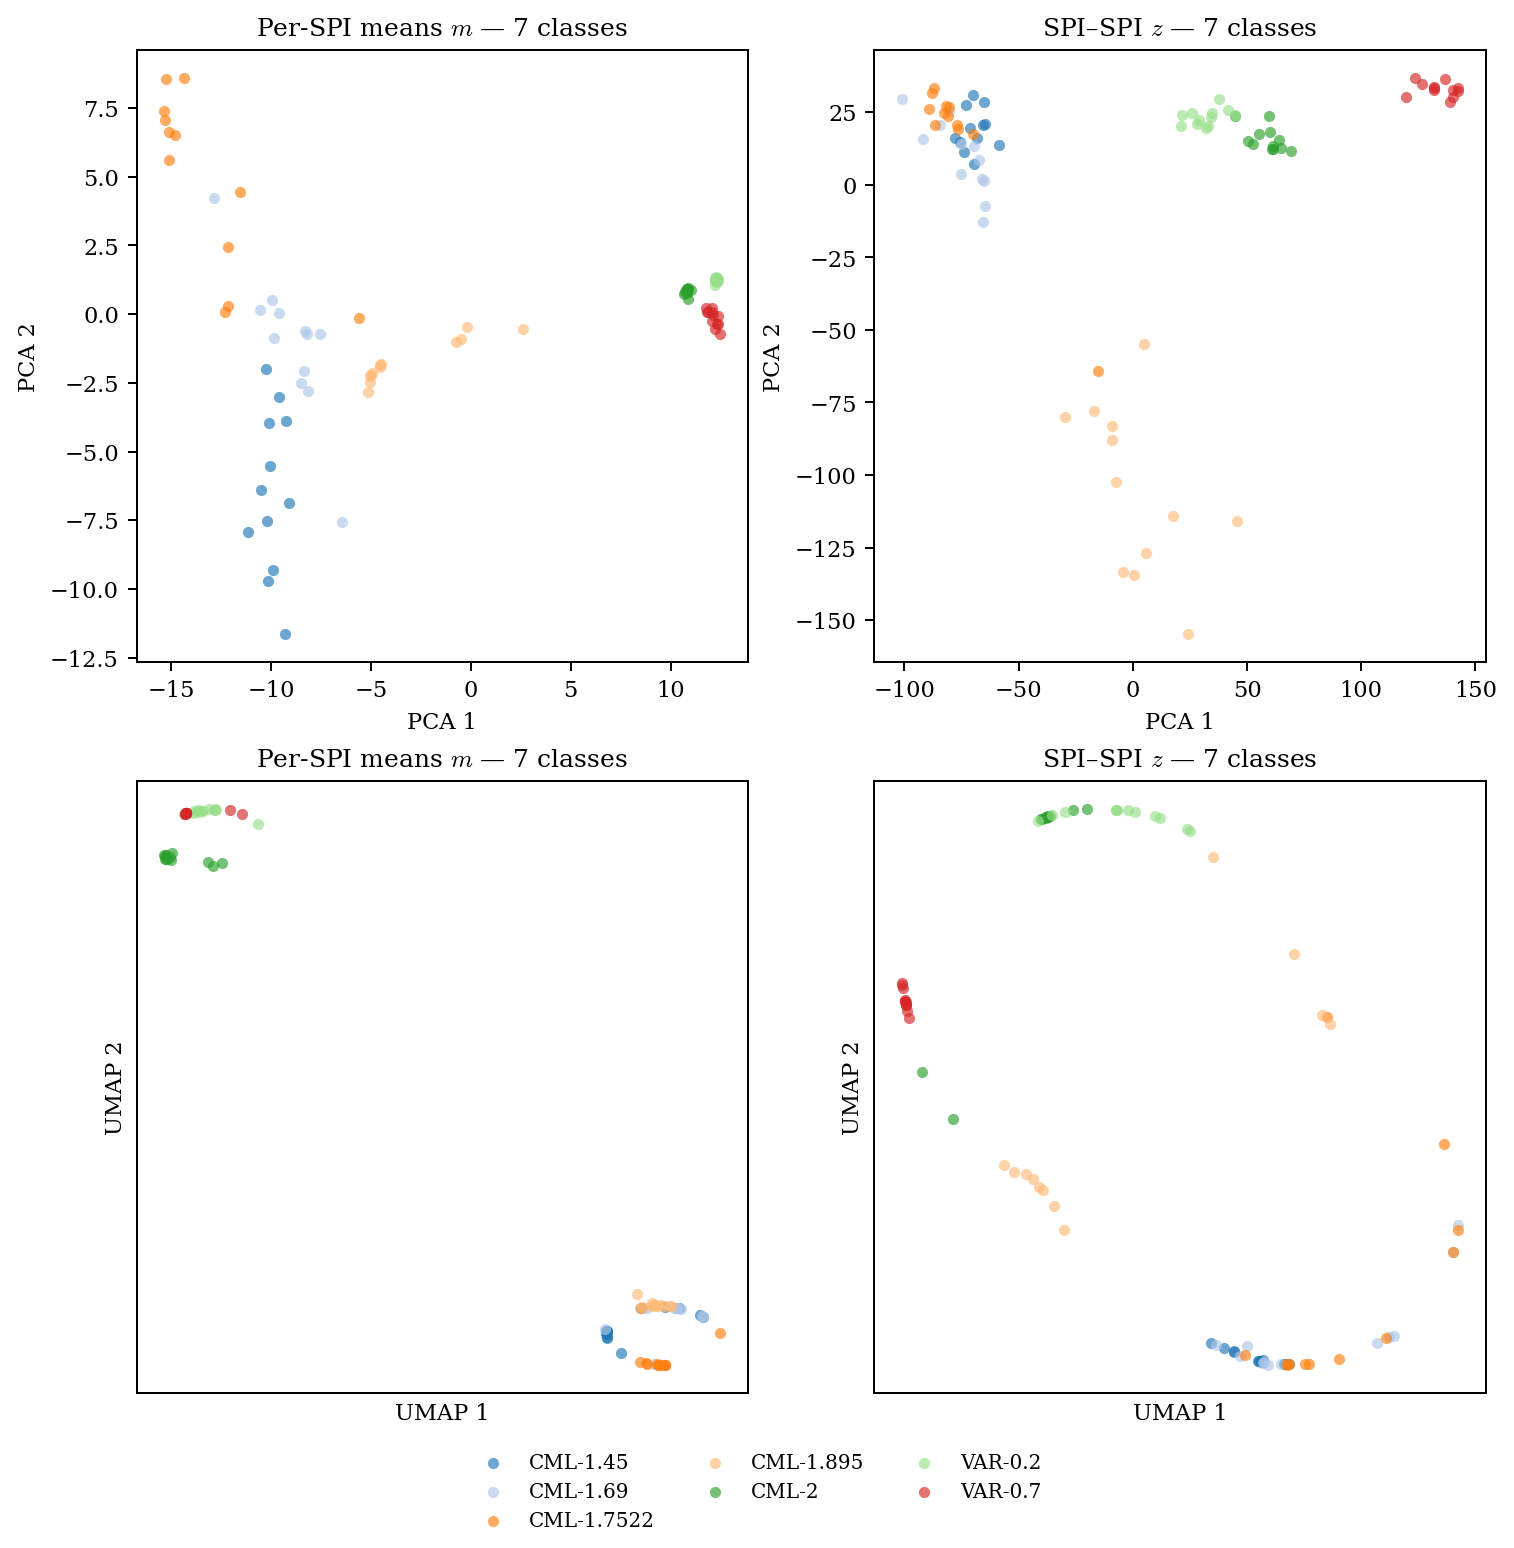

In [3]:
fig=study.plot_embedding('all7')
plt.show()

In [4]:
metrics=pd.read_csv(OUT/'metrics.csv')
primary=metrics[metrics.method.isin(['mean','z','mean_without_PCA'])]
display(primary.round(3))
display(pd.read_csv(OUT/'paired.csv').query("comparison in ['z - mean', 'z - mean_without_PCA']").round(3))

,method,scope,n,balanced_accuracy,low,high,chance
0,mean,all7,84,0.952,0.893,1.0,0.143
1,mean,CML5,60,0.933,0.850,1.0,0.200
4,z,all7,84,0.988,0.964,1.0,0.143
5,z,CML5,60,0.983,0.950,1.0,0.200
14,mean_without_PCA,all7,84,0.964,0.929,1.0,0.143
15,mean_without_PCA,CML5,60,0.950,0.900,1.0,0.200


,scope,comparison,difference,low,high
0,all7,z - mean,0.036,0.0,0.095
1,all7,z - mean_without_PCA,0.024,0.0,0.060
3,CML5,z - mean,0.050,0.0,0.133
4,CML5,z - mean_without_PCA,0.033,0.0,0.083


## Within the quadratic-CML family

These five conditions share a generator family and the calibrated coupling-effect target, while alpha differs. They need not retain the regime identities of the original proof. The classifier is fitted on the CML development rows; preprocessing/PCA20 remains the common development fit, and the displayed CML UMAP is fitted only on CML development rows.

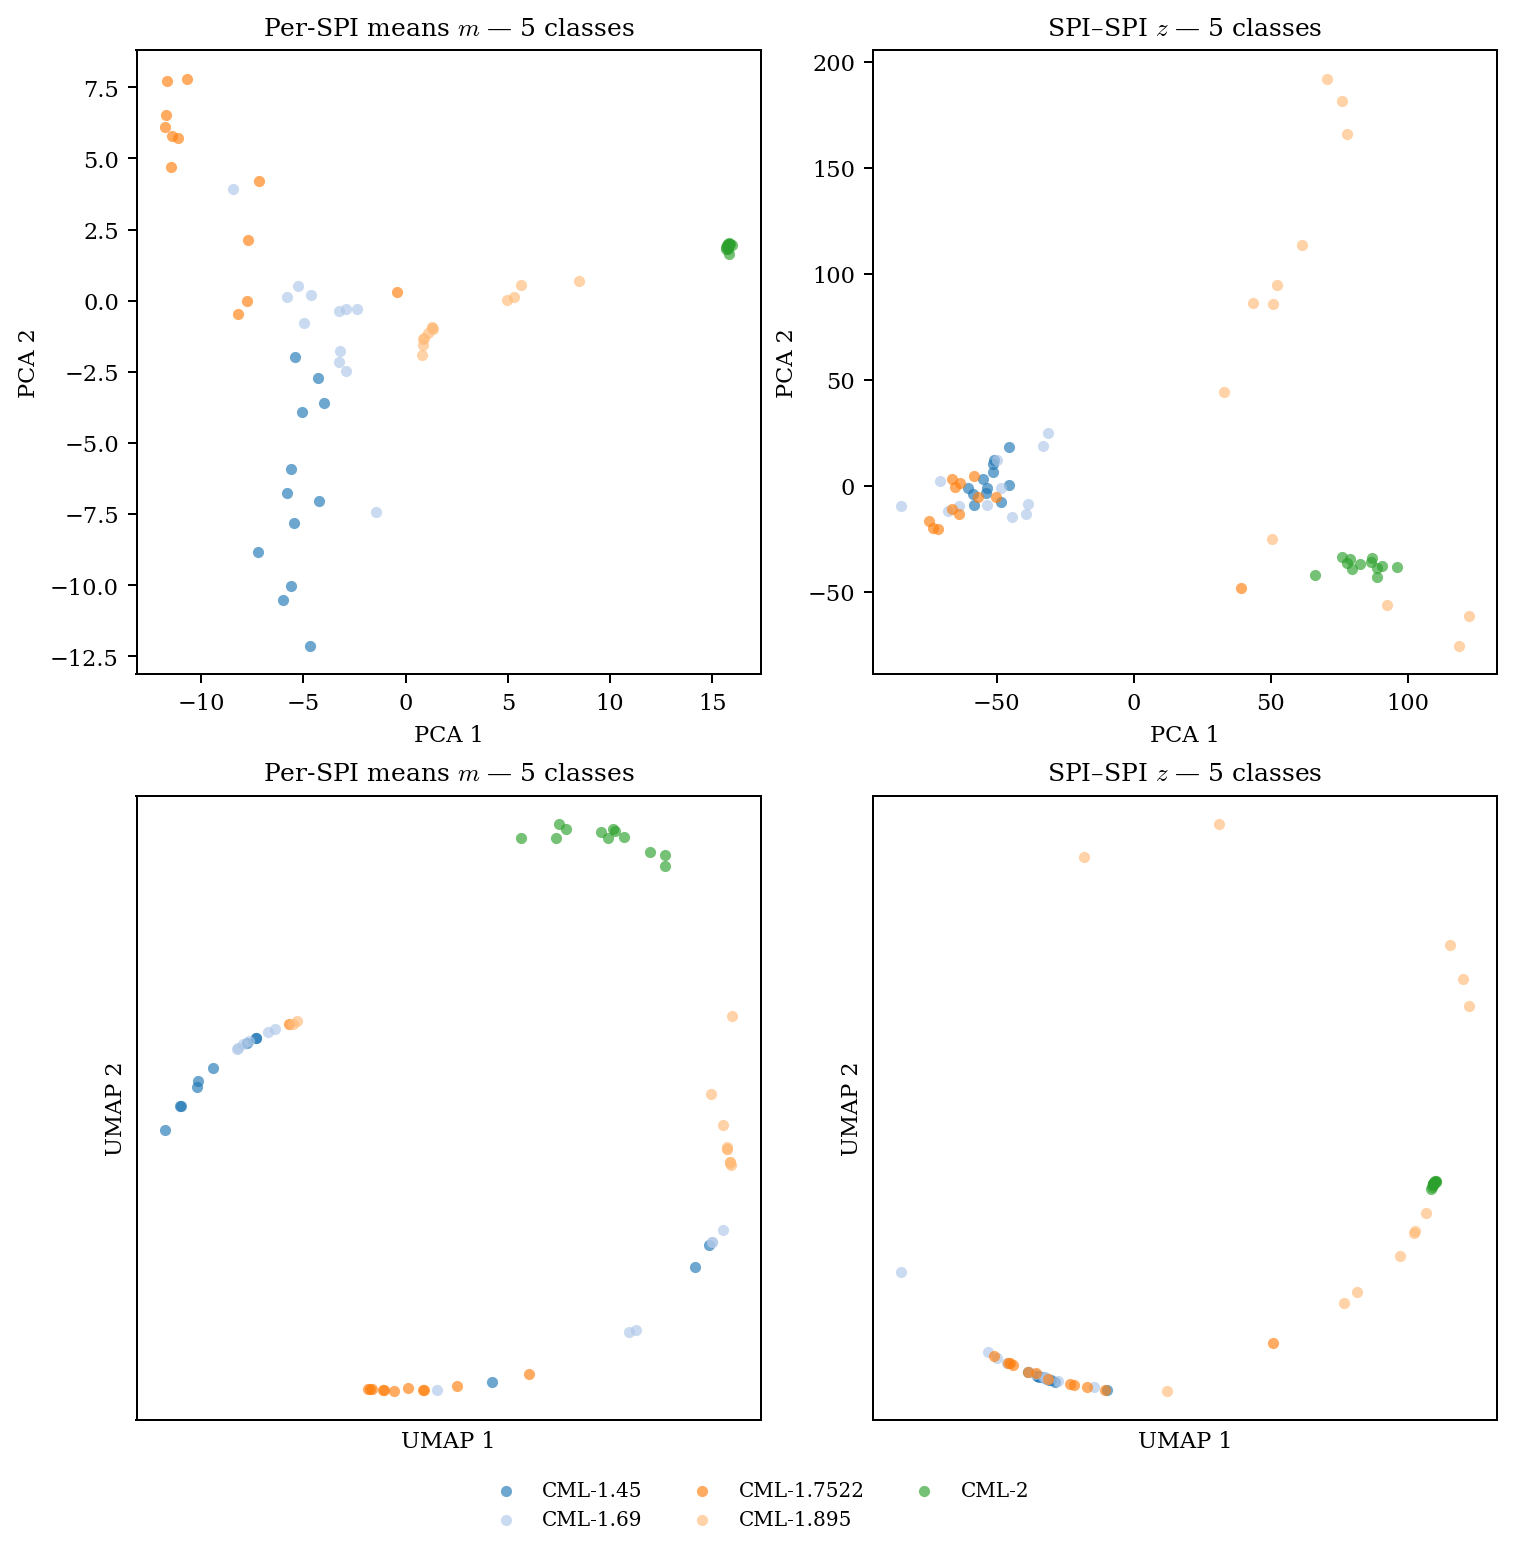

In [5]:
fig=study.plot_embedding('CML5')
plt.show()

## Secondary checks and limits

Seven per-SPI summaries (mean, SD, five quantiles) retain additional marginal information. The validity-only control checks whether patterns of undefined statistics classify the conditions. A separate profile-validity diagnostic checks finite, nonconstant MPI profiles, which also accounts for constant MPIs that make z undefined. The z-validity diagnostic uses the complete binary mask of finite z entries, giving the same feature dimension and preprocessing as z without its values. These diagnostics were added after seeing the pilot results; the primary readout was unchanged. The strength-only control checks residual information in the small allowed calibration error. Confidence intervals and paired differences resample the 12 held seed groups, retaining all classes in each draw; they condition on the fitted models and do not account for training uncertainty or exploratory choices.

Matching a generator-level coupling contribution does not imply equal observed Pearson correlation, equal spectra, or equal means of every SPI. If means still classify well, that is an informative negative result for the proposed separation: marginal SPI responses also describe character under this strength convention. The observed all-seven accuracies are 95.2% for means, 96.4% for means without PCA, and 98.8% for z. The paired z-minus-mean difference is 3.6 percentage points, with a held-block bootstrap interval of 0 to 9.5 points. Thus this pilot does **not** yield unstructured marginals and structured z; the point-estimate gain is modest and uncertain. A stronger z result would instead establish an advantage for the specified representation/readout on this controlled comparison, not universal strength invariance.

In [6]:
display(metrics[~metrics.method.isin(['mean','z','mean_without_PCA'])].round(3))
display(pd.DataFrame(json.loads((OUT/'analysis.json').read_text())['diagnostics']).T.round(3))

,method,scope,n,balanced_accuracy,low,high,chance
2,distribution,all7,84,0.976,0.940,1.000,0.143
3,distribution,CML5,60,0.967,0.917,1.000,0.200
6,validity,all7,84,0.488,0.417,0.560,0.143
7,validity,CML5,60,0.683,0.583,0.783,0.200
8,profile_validity,all7,84,0.524,0.429,0.631,0.143
9,profile_validity,CML5,60,0.700,0.583,0.800,0.200
10,z_validity,all7,84,0.583,0.488,0.667,0.143
11,z_validity,CML5,60,0.783,0.683,0.867,0.200
12,strength_only,all7,84,0.333,0.238,0.440,0.143
13,strength_only,CML5,60,0.283,0.150,0.417,0.200


,features,components,held_max_selected_missing_fraction,held_mean_selected_missing_fraction,explained_variance
mean,218.0,20.0,0.138,0.002,0.992
distribution,1567.0,20.0,0.134,0.002,0.976
z,21856.0,20.0,0.279,0.004,0.868
validity,89.0,20.0,0.000,0.000,0.998
profile_validity,114.0,20.0,0.000,0.000,0.992
z_validity,25669.0,20.0,0.000,0.000,0.990
strength_only,1.0,1.0,0.000,0.000,1.000


## Separate cached diagnostic

This is **not** the generator-level manipulation above: within each historical MPI, subtracting its mean and dividing by its SD sets its mean and SD by construction while preserving Pearson SPI–SPI. Nevertheless, the remaining five normalized quantiles retain substantial class information. The table is included only to distinguish removal of MPI location/scale from physical coupling normalization. Constant/undefined profiles remain missing; the validity-only control is reported. It uses the original retrospective 14-class/five-CML split, not the new seven conditions.

In [7]:
display(pd.read_csv(ROOT/'results/baseline-strength-audit_261003/metrics.csv').round(3))

,method,scope,balanced_accuracy,hard_mAP,n,chance
0,mean,all14,0.907,0.698,2520,0.071
1,mean,CML5,0.976,0.741,900,0.200
2,distribution,all14,0.925,0.714,2520,0.071
3,distribution,CML5,0.986,0.766,900,0.200
4,z,all14,0.983,0.818,2520,0.071
5,z,CML5,0.991,0.940,900,0.200
6,shape,all14,0.955,0.534,2520,0.071
7,shape,CML5,0.978,0.647,900,0.200
8,validity,all14,0.621,0.349,2520,0.071
9,validity,CML5,0.634,0.441,900,0.200


Reproduction: `python -m scripts.calibrate_native_coupling scout` and `build` prepare the calibrated inputs (build refuses to replace an existing bank). The external p90 configuration is `configs/external/native-gain-261003.yaml`; the generator protocol is `configs/analysis/native-coupling-261003.yaml`. After retrieving the cached MPIs, `python -m scripts.analyze_native_coupling extract` and `analyze` produce the audited feature bank, predictions and tables. This notebook only renders those results. Original proof and baseline notebooks are preserved.